# Test-time correction for InvA / AFinal mismatch

This notebook implements a small test-time reconstruction algorithm for the artifacts caused by `InvA @ AFinal != I`.

The normal fast reconstruction is:

```python
x0 = InvA @ y
```

where `y` is the corrected SPEN data. Since `InvA` is a weighted adjoint rather than a true inverse, `x0` contains structured artifacts. Here we refine `x0` by optimizing the image itself:

```text
x* = argmin_x ||AFinal @ x - y||^2
           + lambda_tv * TV(|x|)
           + lambda_close * ||x - x0||^2
```

The optimization uses only the measured data `y`, `AFinal`, and the `InvA` initialization. Ground truth is used only in this synthetic demo to report metrics.


In [4]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from PIL import Image
import scipy.io
import torch
import torch.nn.functional as F

torch.set_grad_enabled(False)


def find_spenpy_repo() -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        for candidate in (base, base / 'spenpy'):
            if (candidate / 'spenpy/data/brain.png').exists() and (candidate / 'spenpy/spen.py').exists():
                return candidate
    fallback = Path('/home/data1/musong/workspace/python/spen_recons/spenpy')
    if (fallback / 'spenpy/data/brain.png').exists():
        return fallback
    raise FileNotFoundError('Could not locate the local spenpy repository')


SPENPY_REPO = find_spenpy_repo()
if str(SPENPY_REPO) not in sys.path:
    sys.path.insert(0, str(SPENPY_REPO))

from spenpy.core import calcInvA


def find_recons_root() -> Path:
    for base in (SPENPY_REPO, *SPENPY_REPO.parents):
        if (base / 'data/mat').exists():
            return base
    fallback = Path('/home/data1/musong/workspace/python/spen_recons')
    if (fallback / 'data/mat').exists():
        return fallback
    raise FileNotFoundError('Could not locate the spen_recons data directory')


RECONS_ROOT = find_recons_root()
SCANNER_MAT_PATH = RECONS_ROOT / 'data/mat/20231011_lxj_SPEN_data_231011_3_1_3/slice_19.mat'


def pil_to_float_tensor(path: Path) -> torch.Tensor:
    image = Image.open(path).convert('L')
    data = torch.frombuffer(bytearray(image.tobytes()), dtype=torch.uint8).to(torch.float32)
    return data.reshape(image.height, image.width) / 255.0


def robust_abs01(value: torch.Tensor, percentile: float = 99.5) -> torch.Tensor:
    value = value.abs() if torch.is_complex(value) else value.float().abs()
    value = value.to(torch.float32)
    positive = value[value > 0]
    if positive.numel() == 0:
        scale = torch.tensor(1.0, dtype=value.dtype, device=value.device)
    else:
        scale = torch.quantile(positive, percentile / 100.0).clamp_min(1e-8)
    return torch.clamp(value / scale, 0.0, 1.0)


def fit_complex_gain(source: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    denom = (source.conj() * source).sum().real.clamp_min(1e-12)
    return (source.conj() * target).sum() / denom


def build_scanner_matrices(mat_path: Path) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    mat = scipy.io.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    args = torch.as_tensor(mat['calc_inva_params'].full_args, dtype=torch.float64).flatten()
    inv_a, a_final = calcInvA(
        args[0],
        args[1],
        int(args[2].item()),
        args[3],
        int(args[4].item()),
        args[5],
        args[6],
    )
    return inv_a.to(torch.complex64), a_final.to(torch.complex64), args


def complex_to_ri(value: torch.Tensor) -> torch.Tensor:
    return torch.stack([value.real, value.imag], dim=0).detach().clone()


def ri_to_complex(value: torch.Tensor) -> torch.Tensor:
    return torch.complex(value[0], value[1])


def total_variation_magnitude(value: torch.Tensor) -> torch.Tensor:
    mag = value.abs()
    pe_tv = (mag[..., 1:, :] - mag[..., :-1, :]).abs().mean()
    ro_tv = (mag[..., :, 1:] - mag[..., :, :-1]).abs().mean()
    return pe_tv + ro_tv


def nrmse(value: torch.Tensor, reference: torch.Tensor) -> torch.Tensor:
    return torch.linalg.vector_norm(value - reference) / torch.linalg.vector_norm(reference).clamp_min(1e-12)


def show_image(ax, value, title, cmap='gray', vmin=None, vmax=None, colorbar=False):
    image = value.detach().cpu() if isinstance(value, torch.Tensor) else value
    im = ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis('off')
    if colorbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return im


print('SPENPy repo:', SPENPY_REPO)


SPENPy repo: /home/data1/musong/workspace/python/spenpy


## 1. The test-time optimizer

`test_time_reconstruct` is the algorithm. It does three things:

1. Builds an initial image with `InvA @ y`.
2. Fits one global complex gain by requiring `AFinal @ x0` to match `y`. This avoids using ground truth to scale the adjoint output.
3. Optimizes real and imaginary image channels with Adam using data consistency, TV, and a weak closeness term.


In [5]:
def test_time_reconstruct(
    y: torch.Tensor,
    AFinal: torch.Tensor,
    InvA: torch.Tensor,
    *,
    steps: int = 200,
    lr: float = 5e-2,
    tv_weight: float = 5e-5,
    close_weight: float = 1e-4,
    print_every: int = 50,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, list[dict[str, float]]]:
    """Refine one batch of corrected SPEN data with test-time optimization.

    Args:
        y: corrected SPEN data, shape [B, PE, RO], complex.
        AFinal: forward matrix, shape [PE, PE], complex.
        InvA: adjoint reconstruction matrix, shape [PE, PE], complex.
        steps: Adam update count.
        lr: Adam learning rate.
        tv_weight: weight for TV(|x|).
        close_weight: weak penalty that keeps the solution near x0.

    Returns:
        x_opt: optimized complex image, shape [B, PE, RO].
        x0: data-gain-matched InvA initialization.
        data_gain: complex scalar applied to InvA @ y.
        history: list of scalar loss terms.
    """
    if y.ndim == 2:
        y = y.unsqueeze(0)
    y = y.to(torch.complex64)
    AFinal = AFinal.to(y.device).to(torch.complex64)
    InvA = InvA.to(y.device).to(torch.complex64)

    with torch.no_grad():
        x0_raw = torch.matmul(InvA, y)
        # This gain is estimated from data consistency only: no reference image is used.
        data_gain = fit_complex_gain(torch.matmul(AFinal, x0_raw), y)
        x0 = (data_gain * x0_raw).detach()

    param = complex_to_ri(x0).requires_grad_(True)
    optimizer = torch.optim.Adam([param], lr=lr)
    y_energy = y.abs().square().mean().clamp_min(1e-12)
    x0_energy = x0.abs().square().mean().clamp_min(1e-12)
    history: list[dict[str, float]] = []

    def measure(step: int, x_value: torch.Tensor, loss_value: torch.Tensor | None = None):
        with torch.no_grad():
            data_loss = (torch.matmul(AFinal, x_value) - y).abs().square().mean() / y_energy
            tv_loss = total_variation_magnitude(x_value) / x_value.abs().mean().clamp_min(1e-8)
            close_loss = (x_value - x0).abs().square().mean() / x0_energy
            total = data_loss + tv_weight * tv_loss + close_weight * close_loss
            history.append(
                {
                    'step': float(step),
                    'loss': float(total if loss_value is None else loss_value.detach()),
                    'data': float(data_loss),
                    'tv': float(tv_loss),
                    'close': float(close_loss),
                }
            )

    measure(0, x0)
    for step in range(1, steps + 1):
        torch.set_grad_enabled(True)
        optimizer.zero_grad(set_to_none=True)
        x = ri_to_complex(param)
        data_loss = (torch.matmul(AFinal, x) - y).abs().square().mean() / y_energy
        tv_loss = total_variation_magnitude(x) / x.abs().mean().clamp_min(1e-8)
        close_loss = (x - x0).abs().square().mean() / x0_energy
        loss = data_loss + tv_weight * tv_loss + close_weight * close_loss
        loss.backward()
        optimizer.step()
        torch.set_grad_enabled(False)

        if step % print_every == 0 or step == steps:
            measure(step, ri_to_complex(param), loss)

    x_opt = ri_to_complex(param).detach()
    return x_opt, x0, data_gain.detach(), history


## 2. Build a clean forward problem

This synthetic example uses `y = AFinal @ image`, with `AFinal` and `InvA` built from the same scanner `calc_inva_params.full_args` used by notebook 13. Any initial reconstruction error therefore comes from the scanner matrix `InvA` approximation, making it a direct test for the matrix-mismatch artifact from notebook 11.


In [6]:
img_path = SPENPY_REPO / 'spenpy/data/brain.png'

img = pil_to_float_tensor(img_path)
InvA, AFinal, scanner_inva_args = build_scanner_matrices(SCANNER_MAT_PATH)

matrix_size = AFinal.shape[0]
img_model = F.interpolate(
    img[None, None],
    size=(matrix_size, matrix_size),
    mode='bilinear',
    align_corners=False,
)[0, 0]
x_true = img_model.to(torch.complex64).unsqueeze(0)
y_clean = torch.matmul(AFinal, x_true)

# Add a small complex noise term here if you want to stress-test the prior.
noise_std = 0.0
if noise_std:
    torch.manual_seed(0)
    noise = torch.randn_like(y_clean) + 1j * torch.randn_like(y_clean)
    y = y_clean + noise_std * noise.to(torch.complex64)
else:
    y = y_clean

print('scanner mat:', SCANNER_MAT_PATH)
print('calcInvA args:', scanner_inva_args.tolist())
print('image :', tuple(img.shape), '->', tuple(x_true.shape))
print('y     :', tuple(y.shape), y.dtype)
print('InvA  :', tuple(InvA.shape), InvA.dtype)
print('AFinal:', tuple(AFinal.shape), AFinal.dtype)


scanner mat: /home/data1/musong/workspace/python/spen_recons/data/mat/20231011_lxj_SPEN_data_231011_3_1_3/slice_19.mat
calcInvA args: [-61.549570356044924, 3.5, 96.0, -2.0, 1.0, 0.0, 0.8]
image : (256, 256) -> (1, 96, 96)
y     : (1, 96, 96) torch.complex64
InvA  : (96, 96) torch.complex64
AFinal: (96, 96) torch.complex64


## 3. Run test-time reconstruction

The defaults below were chosen to be conservative for this 96 x 96 example. The strongest term is data consistency. TV is deliberately small, and the closeness term is only a weak stabilizer.


In [7]:
x_opt, x0, data_gain, history = test_time_reconstruct(
    y,
    AFinal,
    InvA,
    steps=200,
    lr=5e-2,
    tv_weight=5e-5,
    close_weight=1e-4,
    print_every=25,
)

def data_nrmse(x: torch.Tensor) -> torch.Tensor:
    return nrmse(torch.matmul(AFinal, x), y)


init_img_nrmse = nrmse(x0.abs(), x_true.abs())
opt_img_nrmse = nrmse(x_opt.abs(), x_true.abs())
init_data_nrmse = data_nrmse(x0)
opt_data_nrmse = data_nrmse(x_opt)

print(f'data-derived gain: {data_gain.item():.4g}')
print(f'initial image NRMSE : {init_img_nrmse.item():.4f}')
print(f'optimized image NRMSE: {opt_img_nrmse.item():.4f}')
print(f'initial data NRMSE  : {init_data_nrmse.item():.4f}')
print(f'optimized data NRMSE : {opt_data_nrmse.item():.4f}')
print(f'image NRMSE reduction: {(1.0 - opt_img_nrmse / init_img_nrmse).item() * 100:.1f}%')


data-derived gain: 19.57+0.0776j
initial image NRMSE : 0.1072
optimized image NRMSE: 0.0527
initial data NRMSE  : 0.0797
optimized data NRMSE : 0.0019
image NRMSE reduction: 50.8%


## 4. Optimization trace

The data term should drop quickly. If you add noise, increase `tv_weight` slightly or stop earlier to avoid fitting noise.


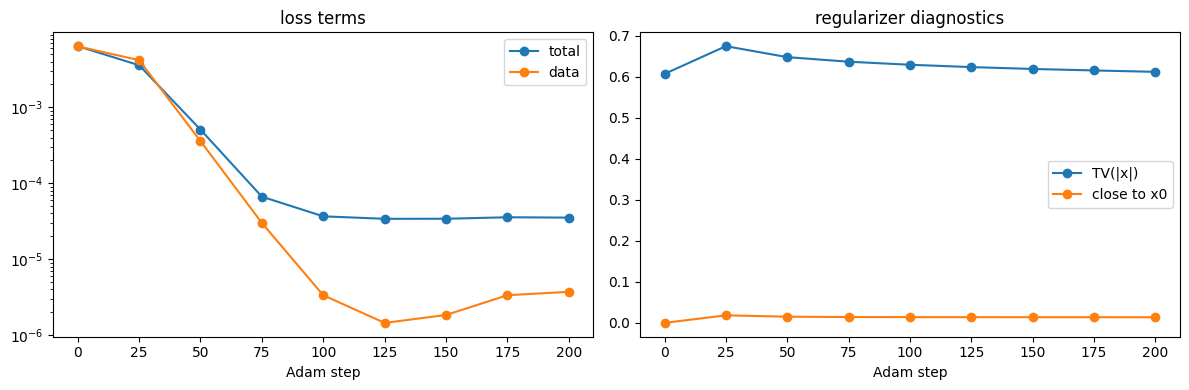

In [8]:
steps = [h['step'] for h in history]
loss_values = [h['loss'] for h in history]
data_values = [h['data'] for h in history]
tv_values = [h['tv'] for h in history]
close_values = [h['close'] for h in history]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(steps, loss_values, marker='o', label='total')
ax[0].plot(steps, data_values, marker='o', label='data')
ax[0].set_yscale('log')
ax[0].set_title('loss terms')
ax[0].set_xlabel('Adam step')
ax[0].legend()

ax[1].plot(steps, tv_values, marker='o', label='TV(|x|)')
ax[1].plot(steps, close_values, marker='o', label='close to x0')
ax[1].set_title('regularizer diagnostics')
ax[1].set_xlabel('Adam step')
ax[1].legend()
plt.tight_layout()


## 5. Visual comparison

The optimized image should keep the anatomy from the `InvA` initialization while reducing the structured residual caused by the non-identity matrix product.


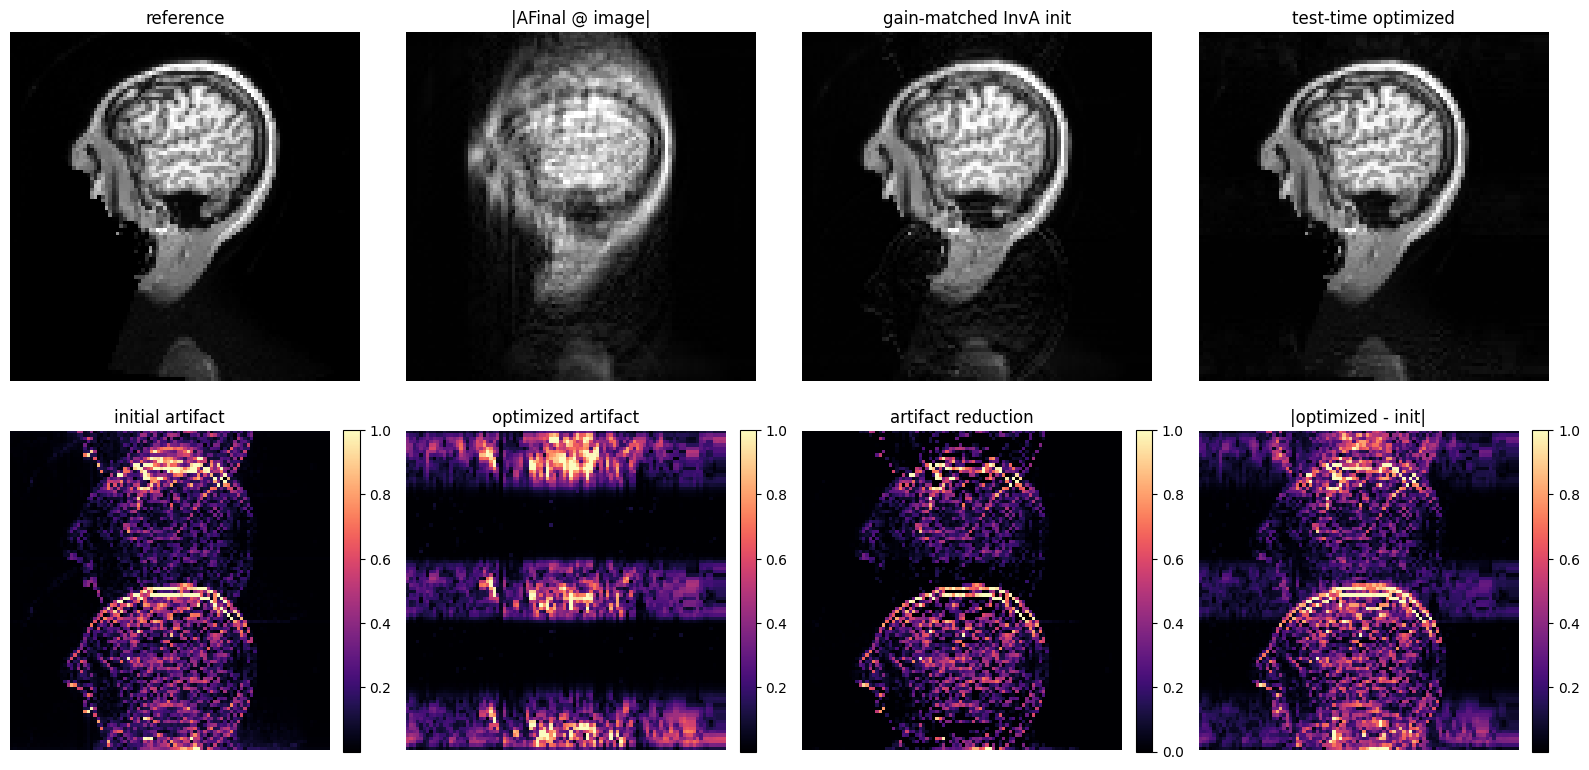

In [9]:
artifact_init = (x0 - x_true).abs()[0]
artifact_opt = (x_opt - x_true).abs()[0]
artifact_reduction = (artifact_init - artifact_opt).clamp_min(0)

fig, ax = plt.subplots(2, 4, figsize=(16, 8))
show_image(ax[0, 0], robust_abs01(x_true[0]), 'reference')
show_image(ax[0, 1], robust_abs01(y[0]), '|AFinal @ image|')
show_image(ax[0, 2], robust_abs01(x0[0]), 'gain-matched InvA init')
show_image(ax[0, 3], robust_abs01(x_opt[0]), 'test-time optimized')

show_image(ax[1, 0], robust_abs01(artifact_init, 99.0), 'initial artifact', cmap='magma', colorbar=True)
show_image(ax[1, 1], robust_abs01(artifact_opt, 99.0), 'optimized artifact', cmap='magma', colorbar=True)
show_image(ax[1, 2], robust_abs01(artifact_reduction, 99.0), 'artifact reduction', cmap='magma', colorbar=True)
show_image(ax[1, 3], robust_abs01((x_opt - x0).abs()[0], 99.0), '|optimized - init|', cmap='magma', colorbar=True)
plt.tight_layout()


## 6. What changed relative to `InvA @ AFinal - I`?

The initial artifact is exactly the result of applying the matrix mismatch to the image. The optimized result is no longer just `E @ image`; it is the solution of a data-consistent inverse problem. This is the point of the test-time algorithm: it uses `AFinal` directly instead of trusting `InvA` as if it were a true inverse.


max |predicted initial artifact - measured initial artifact|: 3.9488e-07
mean initial artifact : 9.8075e-03
mean optimized artifact: 6.7690e-03
max initial artifact  : 1.3645e-01
max optimized artifact : 6.9373e-02


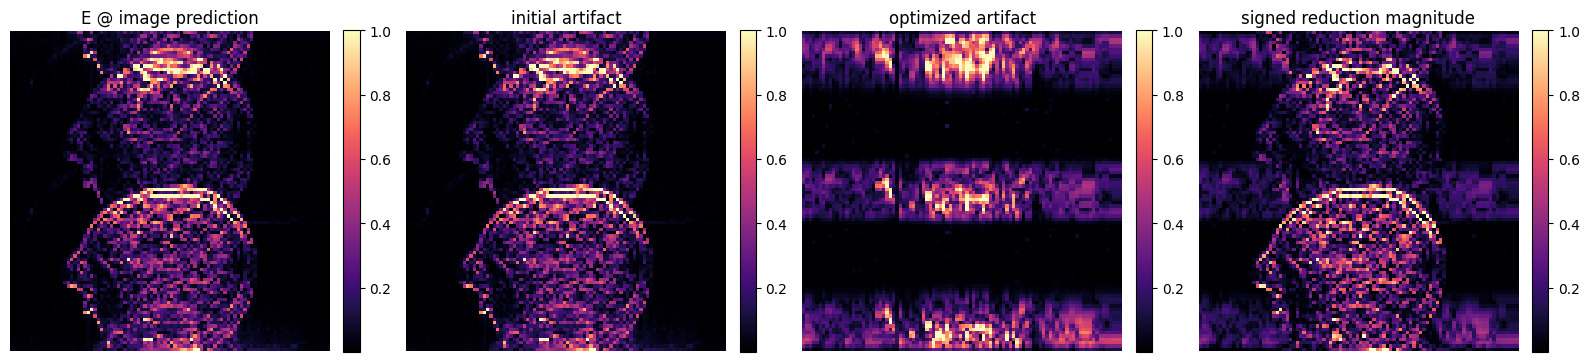

In [10]:
M_init = data_gain * torch.matmul(InvA, AFinal)
I = torch.eye(M_init.shape[0], dtype=M_init.dtype, device=M_init.device)
predicted_init_artifact = torch.matmul(M_init - I, x_true).abs()[0]
prediction_residual = (predicted_init_artifact - artifact_init).abs().max()

print(f'max |predicted initial artifact - measured initial artifact|: {prediction_residual.item():.4e}')
print(f'mean initial artifact : {artifact_init.mean().item():.4e}')
print(f'mean optimized artifact: {artifact_opt.mean().item():.4e}')
print(f'max initial artifact  : {artifact_init.max().item():.4e}')
print(f'max optimized artifact : {artifact_opt.max().item():.4e}')

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
show_image(ax[0], robust_abs01(predicted_init_artifact, 99.0), 'E @ image prediction', cmap='magma', colorbar=True)
show_image(ax[1], robust_abs01(artifact_init, 99.0), 'initial artifact', cmap='magma', colorbar=True)
show_image(ax[2], robust_abs01(artifact_opt, 99.0), 'optimized artifact', cmap='magma', colorbar=True)
show_image(ax[3], robust_abs01(artifact_init - artifact_opt, 99.0), 'signed reduction magnitude', cmap='magma', colorbar=True)
plt.tight_layout()


## Using this with phase-corrected scanner data

For real or simulated phase-corrupted data, use this optimizer after even-row phase correction:

```python
corrected = corrupted.clone()
corrected[:, 1::2, :] *= torch.exp(-1j * phase_map)

x_opt, x0, gain, history = test_time_reconstruct(
    corrected,
    AFinal,
    InvA,
    steps=200,
    tv_weight=5e-5,
    close_weight=1e-4,
)
```

If phase correction is imperfect, this image-only optimizer cannot explain all artifacts. The next extension would optimize `x` and a smooth even-row phase map together.
